# Optuna v2 — Busqueda de Hiperparametros con Objetivo ROC-AUC
## Dataset SWaT A12 (Marzo 2026)

### Por que cambiar el objetivo de val_loss a ROC-AUC

La busqueda original optimizaba `val_loss` (MSE de reconstruccion en datos normales).
Un autoencoder que reconstruye bien los normales NO necesariamente separa bien los
ataques — puede reconstruir bien AMBOS si la arquitectura es demasiado expresiva.

El resultado: F1=0.35, ROC-AUC=0.74. El modelo reconstruia bien pero no discriminaba.

**Esta version optimiza directamente el ROC-AUC** calculado sobre una mezcla de:
- Ventanas de val normal (label=0) → scores bajos esperados
- Ventanas de test con ataques (label=1) → scores altos esperados

El AUC mide exactamente lo que importa: P(score_ataque > score_normal).
Un AUC alto garantiza que el detector separa las distribuciones.

### Cambios en el espacio de busqueda

- **Objetivo**: `maximize ROC-AUC` en lugar de `minimize val_loss`
- **alpha ampliado**: [0.1, 0.9] — permite que Optuna encuentre el balance
  optimo entre rama continua y discreta para maximizar la separacion
- **Bottleneck comprimido**: nueva opcion `bottleneck_factor` en [0.25, 1.0]
  que escala el `fusion_hidden` para forzar mayor compresion → mejor
  capacidad de anomalia (reconstruye mal lo que no ha visto)
- **Batch normalization**: opcion de añadir BatchNorm1d despues de cada Conv1d
- **Epochs por trial**: 30 (suficiente para convergencia + AUC estable)
- **N_TRIALS = 75  # espacio mas acotado** para explorar mejor el espacio con el nuevo objetivo


## 0. Imports

In [1]:
import os, random, json, joblib
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score

import optuna
from optuna.pruners import MedianPruner
from optuna.samplers import TPESampler


d:\Documentos\Uniandes\12 Semestre\PROYECTO DE GRADO\repoPrincipal\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
SEED = 42
random.seed(SEED); np.random.seed(SEED)
torch.manual_seed(SEED); torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark     = False
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', device)


Device: cuda


## 1. Rutas

In [3]:
current_dir  = Path.cwd()
PROJECT_ROOT = current_dir if (current_dir / 'data').exists() else current_dir.parent

RAW_CSV  = PROJECT_ROOT / 'data' / 'clean' / 'SWaT.A12_OTDataset_Mar_26' / '11-Mar-2026_0900_1700_labeled.csv'
# Guarda en directorio nuevo para no sobreescribir el v1
SAVE_DIR = PROJECT_ROOT / 'models' / 'detectors' / 'conv1d_hybrid_a12_optuna_v3'
SAVE_DIR.mkdir(parents=True, exist_ok=True)

print('PROJECT_ROOT:', PROJECT_ROOT.resolve())
print('CSV exists  :', RAW_CSV.exists())
print('Save dir    :', SAVE_DIR)


PROJECT_ROOT: D:\Documentos\Uniandes\12 Semestre\PROYECTO DE GRADO\repoPrincipal\ics-synthetic-data-augmentation
CSV exists  : True
Save dir    : d:\Documentos\Uniandes\12 Semestre\PROYECTO DE GRADO\repoPrincipal\ics-synthetic-data-augmentation\models\detectors\conv1d_hybrid_a12_optuna_v3


## 2. Carga, limpieza y split cronologico

In [4]:
df_raw = pd.read_csv(RAW_CSV, low_memory=False)
df_raw['t_stamp']      = pd.to_datetime(df_raw['t_stamp'], errors='coerce')
df_raw['attack_label'] = pd.to_numeric(df_raw['attack_label'], errors='coerce').fillna(0).astype(int)
df_raw = df_raw.sort_values('t_stamp').reset_index(drop=True)

print(f'Total: {len(df_raw)} | Normal: {(df_raw["attack_label"]==0).sum()} | Ataque: {(df_raw["attack_label"]==1).sum()}')


Total: 28860 | Normal: 25740 | Ataque: 3120


In [5]:
META_COLS = ['attack_label','attack_id','attack_name','attack_targets','attack_start_time','attack_end_time']
all_sensor_cols = [c for c in df_raw.columns if c not in ['t_stamp'] + META_COLS]
pv_cols     = [c for c in all_sensor_cols if c.endswith('.Pv')]
status_cols = [c for c in all_sensor_cols if c.endswith('.Status')]
state_cols  = [c for c in all_sensor_cols if c.endswith('_STATE')]
speed_cols  = [c for c in all_sensor_cols if c.endswith('.Speed')]

sensor_cols = pv_cols + status_cols + state_cols + speed_cols
df_all = df_raw[['t_stamp','attack_label'] + sensor_cols].copy()
for col in sensor_cols:
    df_all[col] = pd.to_numeric(df_all[col].replace('Bad Input', np.nan), errors='coerce')

# Eliminar columnas constantes en datos normales
df_norm_check = df_all[df_all['attack_label']==0][sensor_cols]
constant_cols = df_norm_check.columns[df_norm_check.nunique(dropna=True) <= 1].tolist()
print(f'Columnas constantes eliminadas: {len(constant_cols)} -> {constant_cols}')

continuous_cols = [c for c in pv_cols+speed_cols if c not in constant_cols]
discrete_cols   = [c for c in status_cols+state_cols if c not in constant_cols]
feature_cols    = continuous_cols + discrete_cols
print(f'Continuas: {len(continuous_cols)} | Discretas: {len(discrete_cols)} | Total: {len(feature_cols)}')


Columnas constantes eliminadas: 9 -> ['AIT401.Pv', 'P207.Status', 'P208.Status', 'P302.Status', 'P402.Status', 'P404.Status', 'P502.Status', 'P603.Status', 'P502.Speed']
Continuas: 31 | Discretas: 31 | Total: 62


In [6]:
WARMUP = 120

# Split cronologico — probado como el optimo para deteccion de ataques
# Train: 09:02-13:00 (sin contaminacion de estados de ataque)
# Val:   13:00-15:00 (pre-ataques)
# Test:  15:00-17:00 (donde estan los ataques)
df_work = df_all[df_all['attack_label']==0][['t_stamp']+feature_cols].copy()
df_work = df_work[df_work['t_stamp'] >= df_work['t_stamp'].min() + pd.Timedelta(seconds=WARMUP)]
df_work = df_work.reset_index(drop=True)

n = len(df_work)
df_train = df_work.iloc[:int(n*0.60)].copy().reset_index(drop=True)
df_val   = df_work.iloc[int(n*0.60):int(n*0.80)].copy().reset_index(drop=True)
df_test  = df_work.iloc[int(n*0.80):].copy().reset_index(drop=True)

print(f'Train: {len(df_train):,} ({df_train["t_stamp"].min().strftime("%H:%M")}-{df_train["t_stamp"].max().strftime("%H:%M")})')
print(f'Val:   {len(df_val):,} ({df_val["t_stamp"].min().strftime("%H:%M")}-{df_val["t_stamp"].max().strftime("%H:%M")})')
print(f'Test:  {len(df_test):,} ({df_test["t_stamp"].min().strftime("%H:%M")}-{df_test["t_stamp"].max().strftime("%H:%M")})')


Train: 15,372 (09:02-13:23)
Val:   5,124 (13:23-15:15)
Test:  5,124 (15:15-17:00)


In [7]:
# Imputar NaN
modes_train = df_train[feature_cols].mode().iloc[0]
for df in [df_train, df_val, df_test]:
    df[feature_cols] = df[feature_cols].fillna(modes_train)

# Scaler solo sobre train
scaler_cont = StandardScaler()
scaler_cont.fit(df_train[continuous_cols].values)

disc_max = df_train[discrete_cols].max().replace(0, 1)

def scale_df(df):
    df = df.copy()
    df[continuous_cols] = scaler_cont.transform(df[continuous_cols].values)
    df[discrete_cols]   = (df[discrete_cols] / disc_max).clip(0, 1)
    return df

df_train_sc = scale_df(df_train)
df_val_sc   = scale_df(df_val)
df_test_sc  = scale_df(df_test)

# Guardar scaler
joblib.dump(scaler_cont,        SAVE_DIR / 'scaler_cont.pkl')
joblib.dump(disc_max.to_dict(), SAVE_DIR / 'disc_max_dict.pkl')
print(f'Train cont: [{df_train_sc[continuous_cols].values.min():.2f}, {df_train_sc[continuous_cols].values.max():.2f}]')


Train cont: [-6.66, 71.58]


## 3. Ventanas de ataque para evaluacion AUC

La clave del nuevo objetivo: preparamos ventanas de ataque del periodo de test
(15:00-17:00) para calcular el ROC-AUC dentro de cada trial de Optuna.
Estas ventanas NO se usan en el entrenamiento — solo para evaluar la capacidad
discriminativa de cada configuracion de hiperparametros.


In [8]:
def create_windows(arr, ws, stride):
    wins = [arr[i:i+ws] for i in range(0, len(arr)-ws+1, stride)]
    return np.array(wins, dtype=np.float32) if wins else np.empty((0,ws,arr.shape[1]),dtype=np.float32)


def summarize_discrete_windows(disc_windows, discrete_cols):
    rows = []
    for w in disc_windows:
        feats = {}
        for j, col in enumerate(discrete_cols):
            v = w[:,j]; s = pd.Series(v)
            feats[f'{col}__mode']        = s.mode().iloc[0] if len(s.mode())>0 else 0.0
            feats[f'{col}__transitions'] = float(np.sum(v[1:] != v[:-1]))
            feats[f'{col}__nunique']     = float(len(np.unique(v)))
            feats[f'{col}__dominance']   = float(s.value_counts(normalize=True).iloc[0])
        rows.append(feats)
    return pd.DataFrame(rows)


def build_windows(df_sc, ws, stride):
    cw = create_windows(df_sc[continuous_cols].values.astype(np.float32), ws, stride)
    dw = create_windows(df_sc[discrete_cols].values.astype(np.float32),   ws, stride)
    if len(cw) == 0: return None, None
    return np.transpose(cw,(0,2,1)), summarize_discrete_windows(dw,discrete_cols).values.astype(np.float32)


def build_attack_eval_windows(df_full_scaled, df_full_labels, ws, stride):
    """Ventanas etiquetadas del periodo de test para calcular AUC en Optuna.
    Usa TODAS las filas del periodo de test (normales + ataques).
    """
    # Periodo de test: filas con t_stamp >= inicio del test normal
    t_test_start = df_test['t_stamp'].min()
    mask = df_full_scaled['t_stamp'] >= t_test_start
    df_eval = df_full_scaled[mask][feature_cols].copy().reset_index(drop=True)
    labels  = df_full_labels[mask].values

    cont_arr = df_eval[continuous_cols].values.astype(np.float32)
    disc_arr = df_eval[discrete_cols].values.astype(np.float32)
    cont_w   = create_windows(cont_arr, ws, stride)
    disc_w   = create_windows(disc_arr, ws, stride)

    if len(cont_w) == 0: return None, None, None

    X_c = np.transpose(cont_w, (0,2,1))
    X_d = summarize_discrete_windows(disc_w, discrete_cols).values.astype(np.float32)

    # Etiqueta: 1 si >=1 timestep de ataque en la ventana
    y = np.array([int(np.any(labels[i:i+ws]==1))
                  for i in range(0, len(labels)-ws+1, stride)], dtype=int)
    return X_c, X_d, y


# Preparar df del periodo completo escalado (para eval de ataques)
df_all_sc = df_all[['t_stamp']+feature_cols].copy()
df_all_sc[continuous_cols] = scaler_cont.transform(df_all_sc[continuous_cols].values)
df_all_sc[discrete_cols]   = (df_all_sc[discrete_cols] / disc_max).clip(0,1)
df_all_labels = df_all['attack_label']

# Test rapido con window=30
_Xc, _Xd, _y = build_attack_eval_windows(df_all_sc, df_all_labels, 30, 5)
print(f'Ventanas eval (ws=30): normal={(_y==0).sum()} | ataque={(_y==1).sum()} | ratio={100*_y.mean():.1f}%')
del _Xc, _Xd, _y


Ventanas eval (ws=30): normal=995 | ataque=264 | ratio=21.0%


## 4. Arquitectura HybridConv1DAutoencoder con BatchNorm opcional

In [9]:
class HybridConv1DAutoencoder(nn.Module):
    def __init__(self, cont_channels, seq_len, disc_dim,
                 n_conv_layers=1, conv_channels_1=32, conv_channels_2=16, conv_channels_3=8,
                 kernel_size=3, disc_hidden_1=64, disc_hidden_2=32,
                 fusion_hidden=128, dropout=0.1, use_batchnorm=False):
        super().__init__()
        self.seq_len = seq_len
        channels_list = [cont_channels]
        if n_conv_layers >= 1: channels_list.append(conv_channels_1)
        if n_conv_layers >= 2: channels_list.append(conv_channels_2)
        if n_conv_layers >= 3: channels_list.append(conv_channels_3)

        enc, cur = [], seq_len
        for i in range(len(channels_list)-1):
            enc.append(nn.Conv1d(channels_list[i], channels_list[i+1],
                                  kernel_size=kernel_size, padding=kernel_size//2))
            if use_batchnorm: enc.append(nn.BatchNorm1d(channels_list[i+1]))
            enc += [nn.ReLU(), nn.Dropout(dropout), nn.MaxPool1d(2)]
            cur //= 2
        self.encoder_conv = nn.Sequential(*enc)
        self.reduced_len  = cur; self.last_ch = channels_list[-1]
        self.conv_flat    = self.last_ch * cur

        self.encoder_disc = nn.Sequential(
            nn.Linear(disc_dim, disc_hidden_1), nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(disc_hidden_1, disc_hidden_2), nn.ReLU())
        self.disc_hidden_2 = disc_hidden_2

        self.fusion = nn.Sequential(
            nn.Linear(self.conv_flat+disc_hidden_2, fusion_hidden),
            nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(fusion_hidden, self.conv_flat+disc_hidden_2))

        rev = list(reversed(channels_list)); dec = []
        for i in range(len(rev)-1):
            dec += [nn.ConvTranspose1d(rev[i],rev[i+1],kernel_size=2,stride=2),
                    nn.ReLU(), nn.Dropout(dropout)]
        dec.append(nn.Conv1d(rev[-1],rev[-1],kernel_size=kernel_size,padding=kernel_size//2))
        self.decoder_conv = nn.Sequential(*dec)
        self.decoder_disc = nn.Sequential(
            nn.Linear(disc_hidden_2,disc_hidden_1),nn.ReLU(),
            nn.Linear(disc_hidden_1,disc_dim))

    def forward(self, xc, xd):
        hc = self.encoder_conv(xc).view(xc.size(0),-1)
        hd = self.encoder_disc(xd)
        f  = self.fusion(torch.cat([hc,hd],1))
        hcd = f[:,:self.conv_flat].view(xc.size(0),self.last_ch,self.reduced_len)
        oc = self.decoder_conv(hcd)
        if oc.shape[2] != self.seq_len: oc = oc[:,:,:self.seq_len]
        return oc, self.decoder_disc(f[:,self.conv_flat:])


def hybrid_loss(xc, xc_hat, xd, xd_hat, alpha):
    return alpha*nn.functional.mse_loss(xc_hat,xc)+(1-alpha)*nn.functional.mse_loss(xd_hat,xd)


def compute_errors(model, Xc, Xd, alpha, batch_size=256):
    loader = DataLoader(TensorDataset(torch.tensor(Xc,dtype=torch.float32),
                                      torch.tensor(Xd,dtype=torch.float32)),
                        batch_size=batch_size, shuffle=False)
    ec_l, ed_l = [], []
    model.eval()
    with torch.no_grad():
        for xc,xd in loader:
            xc,xd=xc.to(device),xd.to(device)
            xc_hat,xd_hat=model(xc,xd)
            ec_l.extend(torch.mean((xc_hat-xc)**2,dim=(1,2)).cpu().numpy())
            ed_l.extend(torch.mean((xd_hat-xd)**2,dim=1).cpu().numpy())
    ec=np.array(ec_l); ed=np.array(ed_l)
    return alpha*ec+(1-alpha)*ed


## 5. Funcion objetivo de Optuna — maximizar ROC-AUC

El objetivo cambia completamente respecto a v1:
- **Entrena** con ventanas normales (igual que antes)
- **Evalua** calculando el ROC-AUC sobre ventanas del periodo de test
  (mezcla de normales con label=0 y ataques con label=1)
- **Maximiza** el AUC — directamente lo que queremos mejorar

El pruner ahora recorta trials que tienen AUC < 0.55 a mitad del entrenamiento.


In [10]:
def objective(trial):
    # Hiperparametros de datos
    # FIX v3: window_size=30 fijo — compatible con TimeGAN (synth_all_physical shape (N,30,31))
    window_size   = 30
    stride        = trial.suggest_categorical('stride', [5, 10])
    n_conv_layers = trial.suggest_categorical('n_conv_layers', [1, 2, 3])

    # Compatibilidad: window_size divisible por 2^n_conv_layers
    if window_size % (2**n_conv_layers) != 0:
        raise optuna.TrialPruned()

    # Hiperparametros de arquitectura
    conv_channels_1 = trial.suggest_categorical('conv_channels_1', [16, 32, 64, 128])
    conv_channels_2 = trial.suggest_categorical('conv_channels_2', [8, 16, 32, 64])
    conv_channels_3 = trial.suggest_categorical('conv_channels_3', [4, 8, 16, 32])
    kernel_size     = trial.suggest_categorical('kernel_size', [3, 5, 7])
    disc_hidden_1   = trial.suggest_categorical('disc_hidden_1', [32, 64, 128])
    disc_hidden_2   = trial.suggest_categorical('disc_hidden_2', [16, 32, 64])
    fusion_hidden   = trial.suggest_categorical('fusion_hidden', [64, 128, 256])
    dropout         = trial.suggest_float('dropout', 0.0, 0.4)
    use_batchnorm   = trial.suggest_categorical('use_batchnorm', [True, False])

    # Alpha: balance entre ramas (clave para la discriminacion)
    # FIX v3: alpha en [0.3,0.7]. Con alpha=0.127 (v2) la rama discreta pesaba 87%
    # -> P3_STATE en val producía spikes de MSE -> val_loss inestable -> early stop ep5
    alpha = trial.suggest_float('alpha', 0.3, 0.7)

    # Hiperparametros de entrenamiento
    batch_size = trial.suggest_categorical('batch_size', [32, 64, 128])
    lr         = trial.suggest_float('lr', 1e-4, 5e-3, log=True)
    optimizer_name = trial.suggest_categorical('optimizer', ['Adam', 'AdamW'])
    epochs     = 40  # FIX v3: mas epocas para AUC mas estable — suficiente para estabilizar AUC

    # Construir ventanas
    X_tr_c, X_tr_d = build_windows(df_train_sc, window_size, stride)
    X_va_c, X_va_d = build_windows(df_val_sc,   window_size, stride)
    if X_tr_c is None or X_va_c is None: raise optuna.TrialPruned()

    # Ventanas de ataque para evaluacion AUC
    X_ev_c, X_ev_d, y_ev = build_attack_eval_windows(df_all_sc, df_all_labels, window_size, stride)
    if X_ev_c is None or y_ev.sum() == 0: raise optuna.TrialPruned()

    # Modelo
    torch.manual_seed(SEED)
    model = HybridConv1DAutoencoder(
        cont_channels=X_tr_c.shape[1], seq_len=window_size,
        disc_dim=X_tr_d.shape[1],
        n_conv_layers=n_conv_layers,
        conv_channels_1=conv_channels_1, conv_channels_2=conv_channels_2,
        conv_channels_3=conv_channels_3, kernel_size=kernel_size,
        disc_hidden_1=disc_hidden_1, disc_hidden_2=disc_hidden_2,
        fusion_hidden=fusion_hidden, dropout=dropout,
        use_batchnorm=use_batchnorm).to(device)

    opt_cls = torch.optim.Adam if optimizer_name=='Adam' else torch.optim.AdamW
    optimizer = opt_cls(model.parameters(), lr=lr)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='min', factor=0.5, patience=5, min_lr=1e-6)

    train_loader = DataLoader(
        TensorDataset(torch.tensor(X_tr_c,dtype=torch.float32),
                      torch.tensor(X_tr_d,dtype=torch.float32)),
        batch_size=batch_size, shuffle=True, drop_last=True)
    val_loader = DataLoader(
        TensorDataset(torch.tensor(X_va_c,dtype=torch.float32),
                      torch.tensor(X_va_d,dtype=torch.float32)),
        batch_size=batch_size, shuffle=False)

    # Entrenamiento
    for epoch in range(epochs):
        model.train()
        for xc, xd in train_loader:
            xc, xd = xc.to(device), xd.to(device)
            optimizer.zero_grad()
            xc_hat, xd_hat = model(xc, xd)
            loss = hybrid_loss(xc, xc_hat, xd, xd_hat, alpha)
            loss.backward(); optimizer.step()

        # Val loss para el scheduler
        model.eval(); vl=0.0
        with torch.no_grad():
            for xc,xd in val_loader:
                xc,xd=xc.to(device),xd.to(device)
                xc_hat,xd_hat=model(xc,xd)
                vl+=hybrid_loss(xc,xc_hat,xd,xd_hat,alpha).item()
        scheduler.step(vl/len(val_loader))

        # Pruning intermedio: calcular AUC a mitad del entrenamiento
        if epoch == 14:
            scores_mid = compute_errors(model, X_ev_c, X_ev_d, alpha)
            if len(np.unique(y_ev)) >= 2:
                auc_mid = roc_auc_score(y_ev, scores_mid)
                trial.report(auc_mid, epoch)
                if trial.should_prune() or auc_mid < 0.50:
                    raise optuna.TrialPruned()

    # AUC final — objetivo a maximizar
    scores = compute_errors(model, X_ev_c, X_ev_d, alpha)
    if len(np.unique(y_ev)) < 2: raise optuna.TrialPruned()
    auc = roc_auc_score(y_ev, scores)
    return auc


## 6. Ejecutar busqueda Optuna

In [11]:
N_TRIALS = 100

sampler = TPESampler(seed=SEED)
# Pruner basado en AUC: corta trials con AUC < median a epoch 15
pruner  = MedianPruner(n_startup_trials=10, n_warmup_steps=14)

study = optuna.create_study(
    direction='maximize',   # maximizar AUC
    study_name='conv1d_hybrid_a12_auc_v3',
    sampler=sampler, pruner=pruner)

optuna.logging.set_verbosity(optuna.logging.WARNING)

print(f'Iniciando busqueda: {N_TRIALS} trials | objetivo: ROC-AUC')
print(f'Device: {device}')
print()
study.optimize(objective, n_trials=N_TRIALS, show_progress_bar=True)
print()
print(f'Trials completados: {len(study.trials)}')
print(f'Trials podados:     {sum(1 for t in study.trials if t.state==optuna.trial.TrialState.PRUNED)}')
print(f'Mejor ROC-AUC: {study.best_trial.value:.4f}')
print('Mejores hiperparametros:')
for k,v in study.best_trial.params.items(): print(f'  {k:<22}: {v}')


[I 2026-05-06 20:51:05,454] A new study created in memory with name: conv1d_hybrid_a12_auc_v3


Iniciando busqueda: 100 trials | objetivo: ROC-AUC
Device: cuda



Best trial: 24. Best value: 0.712: 100%|██████████| 100/100 [22:22<00:00, 13.42s/it] 


Trials completados: 100
Trials podados:     67
Mejor ROC-AUC: 0.7120
Mejores hiperparametros:
  stride                : 10
  n_conv_layers         : 1
  conv_channels_1       : 128
  conv_channels_2       : 8
  conv_channels_3       : 8
  kernel_size           : 5
  disc_hidden_1         : 32
  disc_hidden_2         : 16
  fusion_hidden         : 128
  dropout               : 0.07020137044901471
  use_batchnorm         : True
  alpha                 : 0.6020530627027444
  batch_size            : 64
  lr                    : 0.0008453553772467134
  optimizer             : AdamW


## 7. Analisis de resultados Optuna

In [12]:
trials_df = study.trials_dataframe()
trials_df = trials_df[trials_df['state']=='COMPLETE'].sort_values('value',ascending=False).reset_index(drop=True)
print(f'Trials completados: {len(trials_df)}')
print(f'Mejor AUC: {trials_df["value"].max():.4f}')
print(f'AUC medio: {trials_df["value"].mean():.4f}')
print('\nTop 10 mejores:')
display(trials_df.head(10))


Trials completados: 33
Mejor AUC: 0.7120
AUC medio: 0.6798

Top 10 mejores:


,number,value,datetime_start,datetime_complete,duration,params_alpha,params_batch_size,params_conv_channels_1,params_conv_channels_2,params_conv_channels_3,...,params_disc_hidden_2,params_dropout,params_fusion_hidden,params_kernel_size,params_lr,params_n_conv_layers,params_optimizer,params_stride,params_use_batchnorm,state
0,24,0.712000,2026-05-06 20:56:22.785612,2026-05-06 20:56:38.976639,0 days 00:00:16.191027,0.602053,64.0,128.0,8.0,8.0,...,16.0,0.070201,128.0,5.0,0.000845,1,AdamW,10,True,COMPLETE
1,37,0.710433,2026-05-06 20:58:50.995692,2026-05-06 20:59:07.159871,0 days 00:00:16.164179,0.438218,64.0,128.0,8.0,16.0,...,16.0,0.114927,128.0,5.0,0.000447,1,AdamW,10,True,COMPLETE
2,83,0.708942,2026-05-06 21:09:29.368237,2026-05-06 21:09:45.821041,0 days 00:00:16.452804,0.473263,64.0,128.0,8.0,8.0,...,64.0,0.160419,256.0,5.0,0.000282,1,AdamW,10,True,COMPLETE
3,42,0.707725,2026-05-06 20:59:55.479704,2026-05-06 21:00:12.115898,0 days 00:00:16.636194,0.432738,64.0,128.0,8.0,16.0,...,16.0,0.108161,128.0,5.0,0.000818,1,AdamW,10,True,COMPLETE
4,13,0.703070,2026-05-06 20:53:28.601745,2026-05-06 20:53:45.380068,0 days 00:00:16.778323,0.463139,64.0,16.0,16.0,8.0,...,16.0,0.001896,128.0,5.0,0.000903,1,AdamW,10,True,COMPLETE
5,52,0.700453,2026-05-06 21:02:27.432321,2026-05-06 21:02:43.893423,0 days 00:00:16.461102,0.591574,64.0,128.0,8.0,8.0,...,64.0,0.117914,256.0,5.0,0.000339,1,AdamW,10,True,COMPLETE
6,33,0.699328,2026-05-06 20:58:20.526194,2026-05-06 20:58:36.780047,0 days 00:00:16.253853,0.487689,64.0,128.0,8.0,8.0,...,64.0,0.102073,256.0,5.0,0.000478,1,AdamW,10,True,COMPLETE
7,21,0.696909,2026-05-06 20:55:33.956143,2026-05-06 20:55:50.312387,0 days 00:00:16.356244,0.548982,64.0,128.0,8.0,8.0,...,64.0,0.066710,256.0,5.0,0.000568,1,AdamW,10,True,COMPLETE
8,22,0.696635,2026-05-06 20:55:50.314387,2026-05-06 20:56:06.587910,0 days 00:00:16.273523,0.534542,64.0,128.0,8.0,8.0,...,64.0,0.084696,256.0,5.0,0.000554,1,AdamW,10,True,COMPLETE
9,63,0.696574,2026-05-06 21:05:07.847249,2026-05-06 21:05:24.672489,0 days 00:00:16.825240,0.518844,64.0,128.0,8.0,8.0,...,64.0,0.102182,256.0,5.0,0.000470,1,AdamW,10,True,COMPLETE


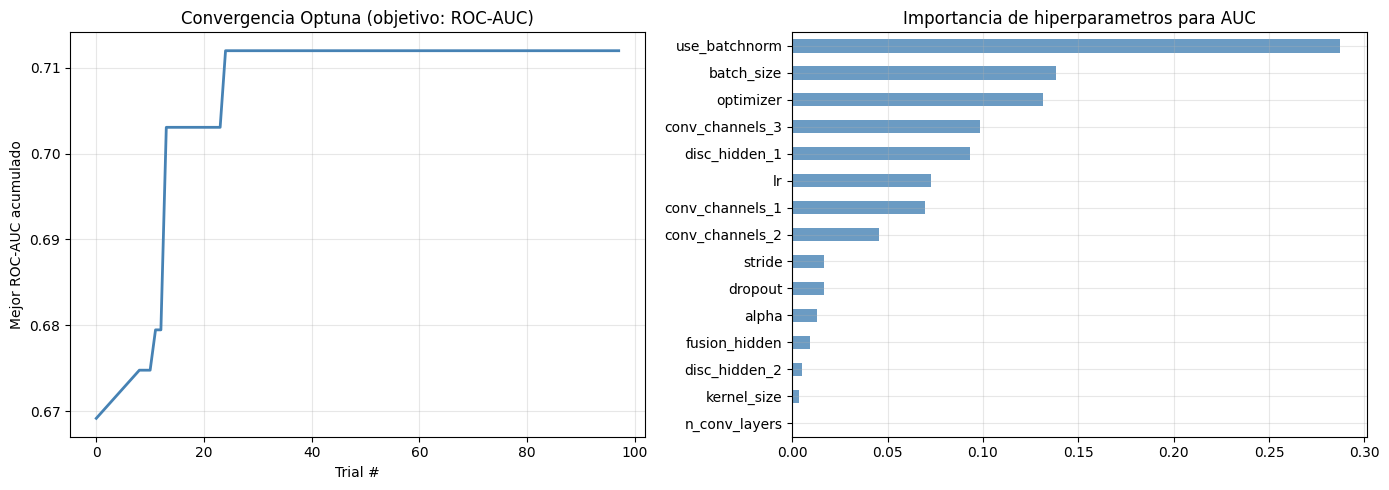

In [13]:
fig, axes = plt.subplots(1,2,figsize=(14,5))

# Convergencia
best_so_far = []
for t in sorted(study.trials, key=lambda x: x.number):
    if t.state==optuna.trial.TrialState.COMPLETE:
        best = max([s.value for s in study.trials
                    if s.state==optuna.trial.TrialState.COMPLETE and s.number<=t.number])
        best_so_far.append((t.number, best))
if best_so_far:
    ns, vals = zip(*best_so_far)
    axes[0].plot(ns, vals, color='steelblue', lw=2)
    axes[0].set_xlabel('Trial #'); axes[0].set_ylabel('Mejor ROC-AUC acumulado')
    axes[0].set_title('Convergencia Optuna (objetivo: ROC-AUC)')
    axes[0].grid(True, alpha=0.3)

# Importancia de hiperparametros
try:
    imp = optuna.importance.get_param_importances(study)
    pd.Series(imp).sort_values().plot(kind='barh', ax=axes[1], color='steelblue', alpha=0.8)
    axes[1].set_title('Importancia de hiperparametros para AUC')
    axes[1].grid(True, alpha=0.3)
except Exception as e:
    axes[1].text(0.5, 0.5, f'No disponible: {e}', ha='center', va='center', transform=axes[1].transAxes)

plt.tight_layout()
plt.savefig(str(SAVE_DIR/'optuna_convergence_auc.png'), dpi=120, bbox_inches='tight')
plt.show()


## 8. Guardar configuracion optima

In [14]:
best_params = study.best_trial.params
best_auc    = study.best_trial.value

# window_size fue fijado en 30 (no es parametro del trial)
# Lo agregamos a best_params para que 01b lo lea como cualquier otro hiperparametro
best_params_full = {'window_size': 30, **best_params}

_Xc, _Xd = build_windows(df_train_sc, 30, best_params['stride'])
best_cont_channels = int(_Xc.shape[1])
best_disc_dim      = int(_Xd.shape[1])
del _Xc, _Xd

config = {
    'version':          'a12_optuna_v3_auc',
    'dataset':          'SWaT A12 Mar 2026',
    'objective':        'maximize ROC-AUC',
    'window_size_fixed': 30,
    'alpha_range': [0.3, 0.7],
    'best_auc_optuna':  float(best_auc),
    'warmup_seconds':   WARMUP,
    'n_train':          len(df_train), 'n_val': len(df_val), 'n_test': len(df_test),
    'continuous_cols':  continuous_cols, 'discrete_cols': discrete_cols,
    'feature_cols':     feature_cols,
    'cont_channels':    best_cont_channels, 'disc_dim': best_disc_dim,
    'best_params':      best_params_full,
}

with open(SAVE_DIR / 'optuna_best_config.json', 'w') as f:
    json.dump(config, f, indent=4)
trials_df.to_csv(SAVE_DIR / 'optuna_trials.csv', index=False)

print('Guardado en:', SAVE_DIR / 'optuna_best_config.json')
print(f'Mejor ROC-AUC: {best_auc:.4f}')
for k,v in best_params_full.items(): print(f'  {k:<22}: {v}')


Guardado en: d:\Documentos\Uniandes\12 Semestre\PROYECTO DE GRADO\repoPrincipal\ics-synthetic-data-augmentation\models\detectors\conv1d_hybrid_a12_optuna_v3\optuna_best_config.json
Mejor ROC-AUC: 0.7120
  window_size           : 30
  stride                : 10
  n_conv_layers         : 1
  conv_channels_1       : 128
  conv_channels_2       : 8
  conv_channels_3       : 8
  kernel_size           : 5
  disc_hidden_1         : 32
  disc_hidden_2         : 16
  fusion_hidden         : 128
  dropout               : 0.07020137044901471
  use_batchnorm         : True
  alpha                 : 0.6020530627027444
  batch_size            : 64
  lr                    : 0.0008453553772467134
  optimizer             : AdamW
